In [1]:
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
import os
proxy = 'http://127.0.0.1:7890' # 代理设置，此处修改
os.environ['HTTP_PROXY'] = proxy
os.environ['HTTPS_PROXY'] = proxy

In [ ]:
# 彻底禁掉代理（见上一节）
for v in ("HTTP_PROXY","HTTPS_PROXY","http_proxy","https_proxy"):
    os.environ.pop(v, None)

In [3]:
# 获取数据函数
def get_stock_closing_prices(ticker_symbol, start_date, end_date):
    """
    获取单只股票在指定日期区间内的收盘价
    :param ticker_symbol: 股票代码 (例如: '600519.SS' 为贵州茅台)
    :param start_date: 开始日期 (格式: 'YYYY-MM-DD')
    :param end_date: 结束日期 (格式: 'YYYY-MM-DD')
    """
    print(f"正在获取 {ticker_symbol} 从 {start_date} 到 {end_date} 的数据...")
    
    # 1. 下载数据
    # auto_adjust=True 会自动调整分红和拆股后的价格
    df = yf.download(ticker_symbol, start=start_date, end=end_date, auto_adjust=True)
    
    # 2. 检查数据是否为空
    if df.empty:
        print("未获取到数据，请检查股票代码或日期范围。")
        return None
    
    # 3. 提取收盘价 (Close)
    # yfinance 返回的是 MultiIndex 列，我们只需要 'Close' 这一列
    closing_prices = df[['Close']]
    
    # 4. 打印前 5 行查看
    print("\n--- 每日收盘价数据 (前5行) ---")
    print(closing_prices.head())
    
    # 5. 可视化（可选）
    plt.figure(figsize=(10, 5))
    plt.plot(closing_prices.index, closing_prices['Close'], label='Close Price')
    plt.title(f'{ticker_symbol} Daily Closing Prices')
    plt.xlabel('Date')
    plt.ylabel('Price (Local Currency)')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return closing_prices

# 获取数据

正在获取 300251.SZ 从 2024-01-01 到 2025-4-30 的数据...


[*********************100%***********************]  1 of 1 completed


--- 每日收盘价数据 (前5行) ---
Price          Close
Ticker     300251.SZ
Date                
2024-01-02  8.054965
2024-01-03  8.084399
2024-01-04  8.015721
2024-01-05  7.848931
2024-01-08  7.711576


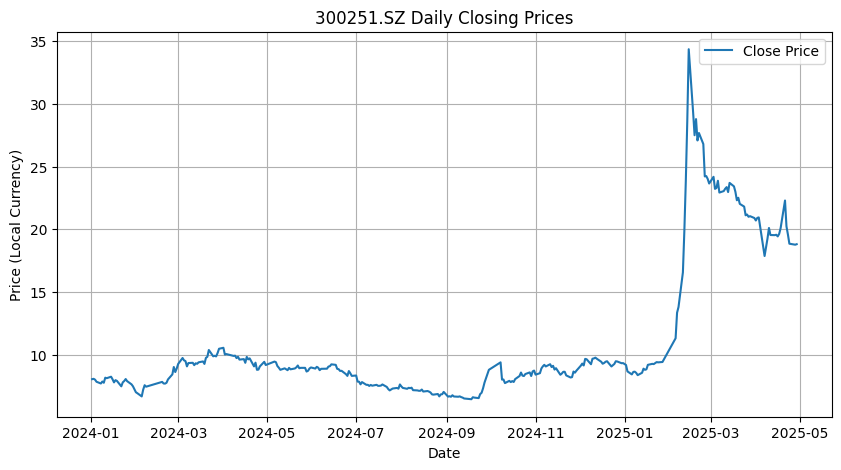

In [4]:
target_stock = "300251.SZ" 
start = "2024-01-01"
end = "2025-4-30"

prices = get_stock_closing_prices(target_stock, start, end) #光线传媒

In [5]:
# 如果需要保存到 CSV 文件
# if prices is not None:
#     prices.to_csv(f"{target_stock}_prices.csv")

正在获取 NVDA 从 2020-01-01 到 2025-12-31 的数据...


[*********************100%***********************]  1 of 1 completed


--- 每日收盘价数据 (前5行) ---
Price          Close
Ticker          NVDA
Date                
2020-01-02  5.971077
2020-01-03  5.875504
2020-01-06  5.900143
2020-01-07  5.971576
2020-01-08  5.982775


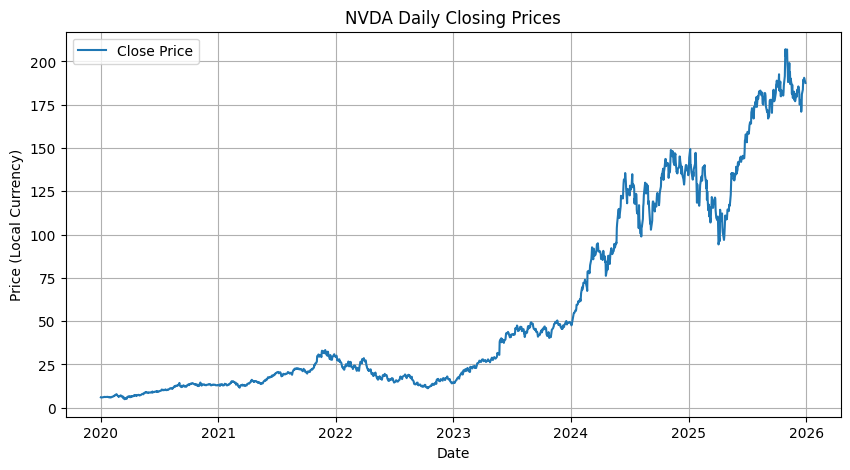

In [6]:
nvidia = get_stock_closing_prices("NVDA", "2020-01-01", "2025-12-31")   #英伟达

正在获取 SNDK 从 2025-07-01 到 2026-1-15 的数据...


[*********************100%***********************]  1 of 1 completed


--- 每日收盘价数据 (前5行) ---
Price           Close
Ticker           SNDK
Date                 
2025-07-01  44.959999
2025-07-02  46.209999
2025-07-03  46.410000
2025-07-07  45.220001
2025-07-08  46.169998


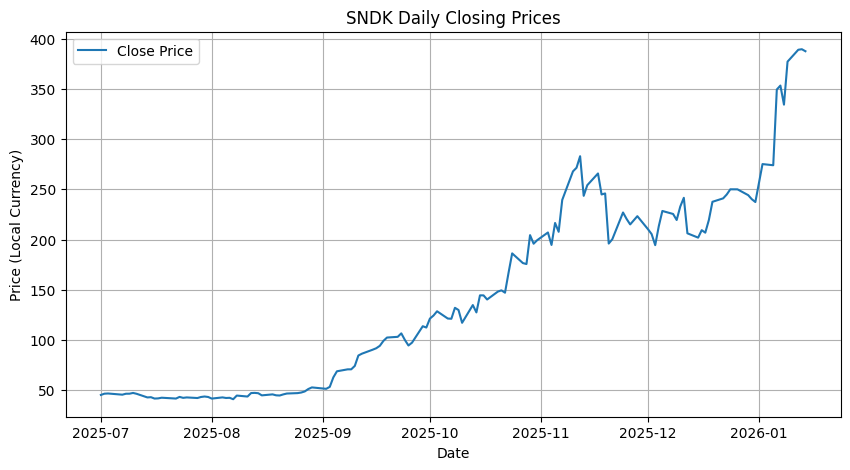

In [7]:
sandisk_data = get_stock_closing_prices("SNDK", "2025-07-01", "2026-1-15")  #闪迪

In [8]:
nvidia

Price,Close
Ticker,NVDA
Date,
2020-01-02,5.971077
2020-01-03,5.875504
2020-01-06,5.900143
2020-01-07,5.971576
2020-01-08,5.982775
...,...
2025-12-23,189.210007
2025-12-24,188.610001


In [10]:
# 如果需要保存到 CSV 文件
nvidia.to_csv("../data/nvidia.csv")
prices.to_csv("../data/300251.csv")
sandisk_data.to_csv("../data/sandisk_data.csv")